In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [57]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [58]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [60]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [61]:
df.shape

(7043, 21)

In [62]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [65]:
df.dropna(inplace=True)

In [66]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

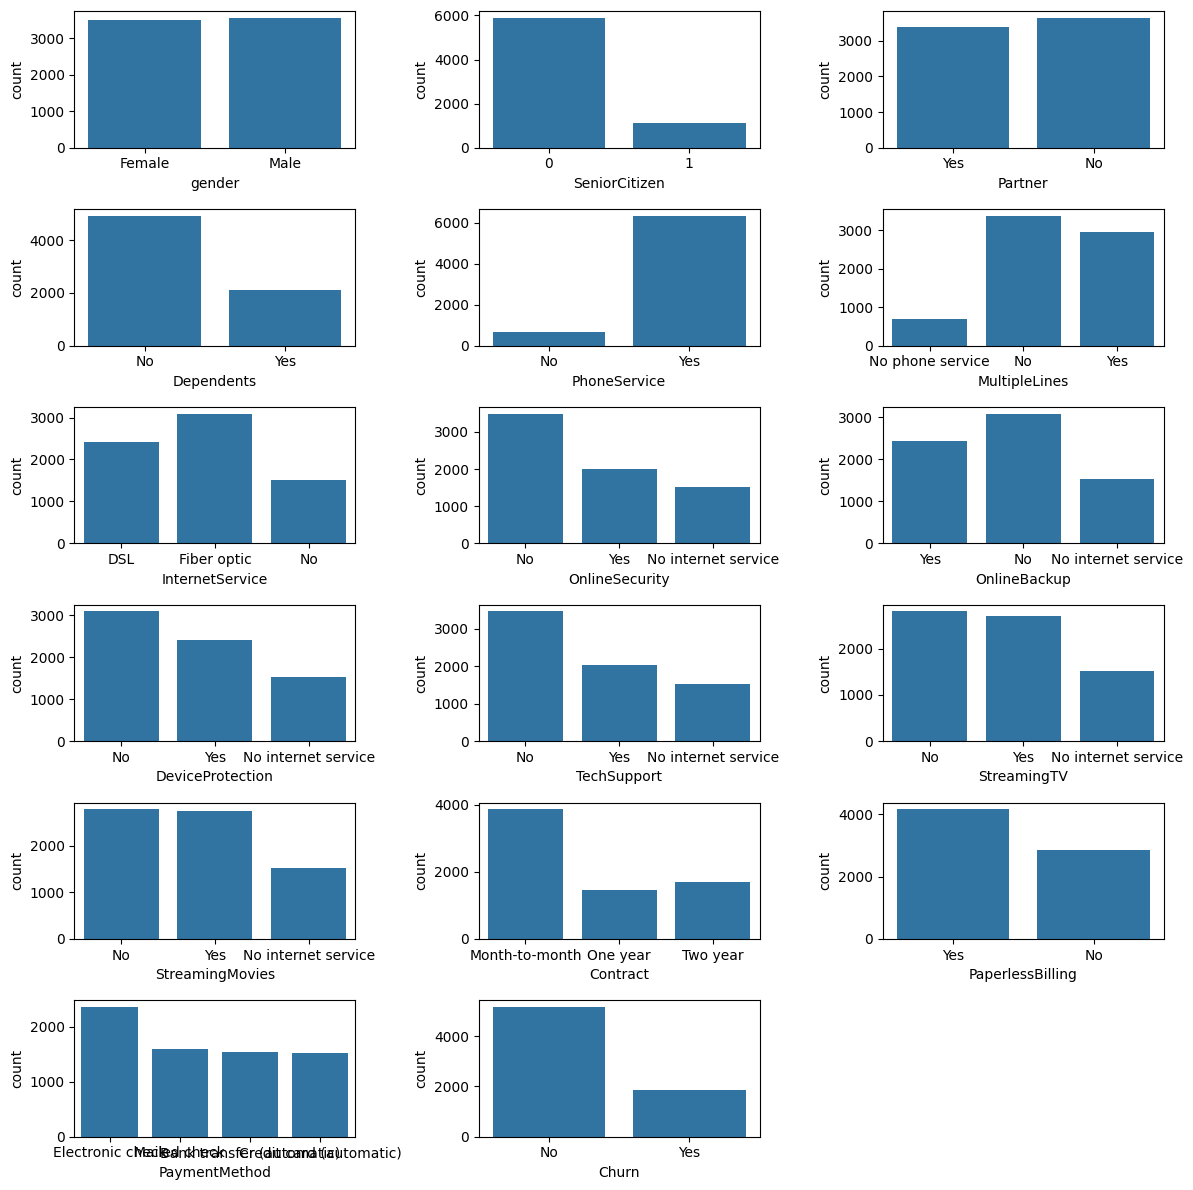

In [67]:
binary_category = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity',
                   'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod',
                   'Churn']

plt.figure(figsize=(12,12))
for i, col in enumerate(binary_category, start=1):
    plt.subplot(6,3,i)
    sns.countplot(x=df[col])
    plt.tight_layout()

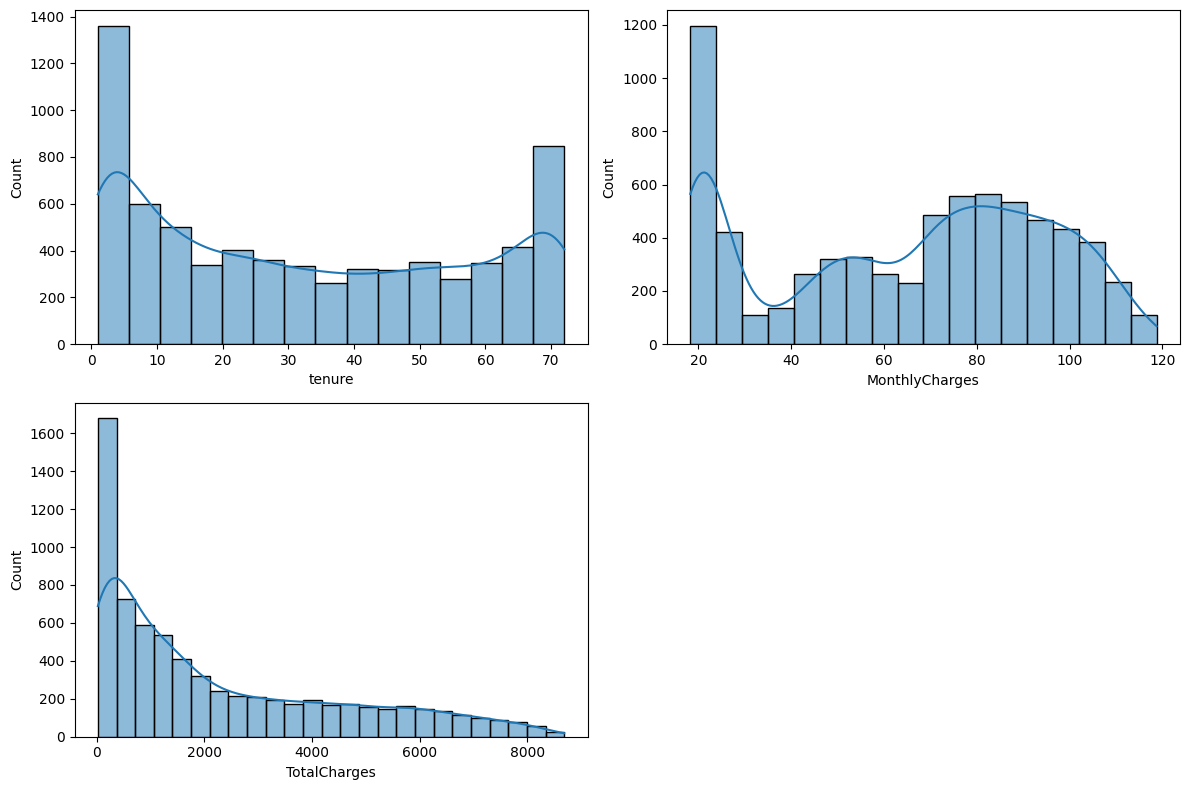

In [68]:
histogram_category = ["tenure","MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(12,8))
for i, col in enumerate(histogram_category, start=1):
    plt.subplot(2,2,i)
    sns.histplot(x=df[col], kde=True)
    plt.tight_layout()

<Axes: >

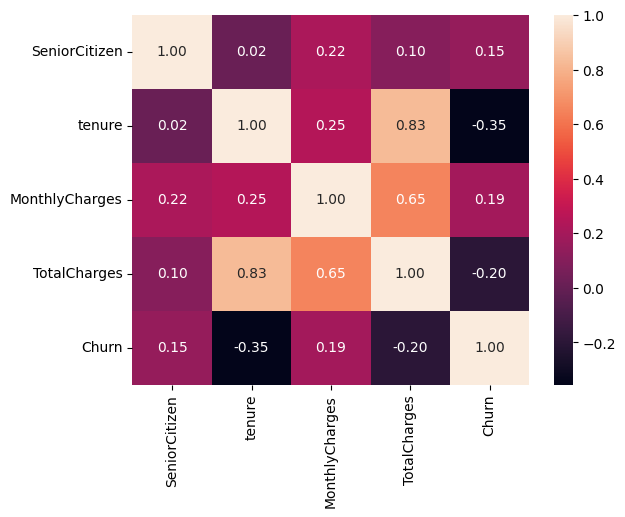

In [69]:
df["Churn"] = df["Churn"].replace({'No':0, 'Yes':1})
sns.heatmap(df.corr(numeric_only=True), fmt='.2f', annot=True)

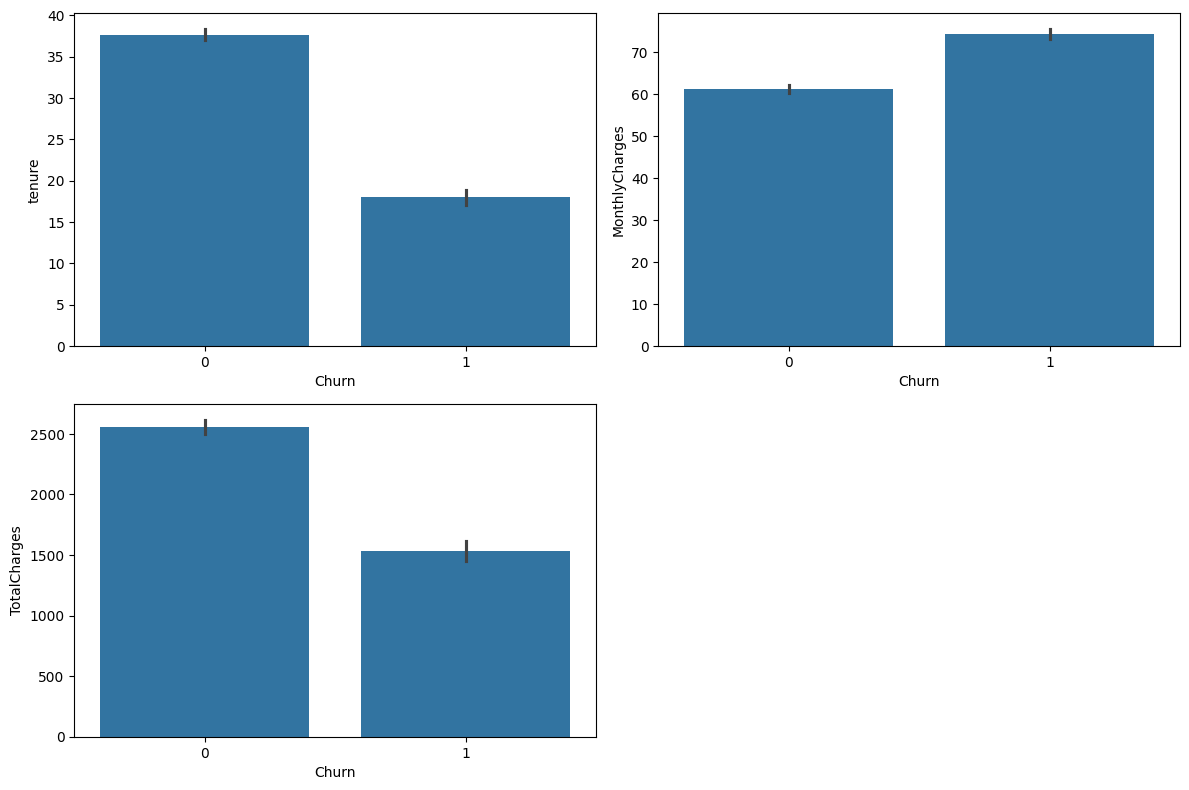

In [70]:
countplot_category = ["tenure","MonthlyCharges","TotalCharges"]
plt.figure(figsize=(12,8))
for i, col in enumerate(histogram_category, start=1):
    plt.subplot(2,2,i)
    sns.barplot(x=df["Churn"], y=df[col])
    plt.tight_layout()

In [71]:
df = df.drop(columns=["customerID"], axis=1)

In [72]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [73]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [74]:
cat_features = df.select_dtypes(include='object').columns

In [75]:
cat_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [76]:
encoders = {}

for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [77]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [78]:
scaler = StandardScaler()
numeric_col = ["tenure","MonthlyCharges","TotalCharges"]
df[numeric_col] = scaler.fit_transform(df[numeric_col])

In [79]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.280248,0,1,0,0,2,0,0,0,0,0,1,2,-1.161694,-0.994194,0
1,1,0,0,0,0.064303,1,0,0,2,0,2,0,0,0,1,0,3,-0.260878,-0.173740,0
2,1,0,0,0,-1.239504,1,0,0,2,2,0,0,0,0,0,1,3,-0.363923,-0.959649,1
3,1,0,0,0,0.512486,0,1,0,2,0,2,2,0,0,1,0,0,-0.747850,-0.195248,0
4,0,0,0,0,-1.239504,1,0,1,0,0,0,0,0,0,0,1,2,0.196178,-0.940457,1


In [80]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [82]:
y_train.value_counts()

Churn
0    3452
1    1259
Name: count, dtype: int64

In [83]:
from imblearn.over_sampling import SMOTE

In [84]:
smote = SMOTE(sampling_strategy=0.8, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [85]:
y_train_smote.value_counts()

Churn
0    3452
1    2761
Name: count, dtype: int64

In [86]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

In [87]:
models = {
    "DecisionTreeClassifier":DecisionTreeClassifier(class_weight="balanced"),
    "SVC":SVC(),
    "LogisticRegression":LogisticRegression(class_weight="balanced"),
    "GaussianNB":GaussianNB(),
    "KNeighborsClassifier":KNeighborsClassifier(n_neighbors=5),
    "RandomForestClassifier":RandomForestClassifier(class_weight="balanced")
}

results = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    results[name] = {
        "Accuracy":accuracy,
        "Recall":recall,
        "Precision":precision,
        "F1 score":f1
    }

In [88]:
result_df = pd.DataFrame(results).T
result_df = result_df.sort_values(by="Accuracy", ascending=False)
result_df

,Accuracy,Recall,Precision,F1 score
RandomForestClassifier,0.763464,0.583607,0.546851,0.564631
SVC,0.762602,0.701639,0.537014,0.608387
LogisticRegression,0.737613,0.785246,0.500522,0.611359
GaussianNB,0.727704,0.755738,0.488347,0.593308
KNeighborsClassifier,0.718225,0.711475,0.475877,0.570302
DecisionTreeClassifier,0.712624,0.583607,0.462939,0.516316


In [89]:
model = RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=None,
                               class_weight='balanced_subsample', random_state=42)
model.fit(X_train_smote, y_train_smote)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Random Forest Model')

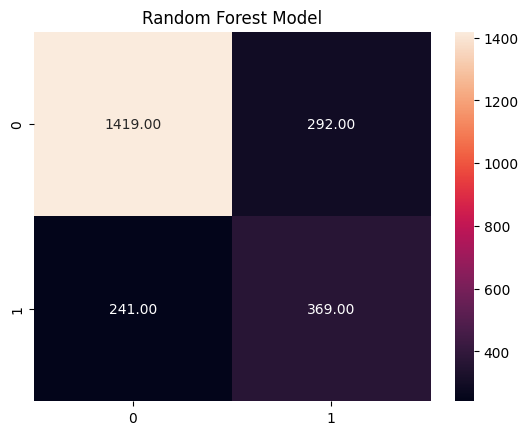

In [91]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f")
plt.title("Random Forest Model")

In [92]:
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

,precision,recall,f1-score,support
0,0.854819,0.829340,0.841887,1711.000000
1,0.558245,0.604918,0.580645,610.000000
accuracy,0.770358,0.770358,0.770358,0.770358
macro avg,0.706532,0.717129,0.711266,2321.000000
weighted avg,0.776874,0.770358,0.773228,2321.000000


In [93]:
from sklearn.model_selection import RandomizedSearchCV

In [46]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=50,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.05,
 'gamma': 0.1,
 'colsample_bytree': 0.7}

In [48]:
random_search.best_score_

np.float64(0.7887481994636945)

In [94]:
from xgboost import XGBClassifier

In [95]:
xgb_model = XGBClassifier(subsample=0.7, n_estimators=200,min_child_weight=1,max_depth=6,learning_rate=0.05,
                         gamma=0.1, colsample_bytree=0.7)
xgb_model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [96]:
xgb_pred = xgb_model.predict(X_test)

In [97]:
accuracy_score(y_test, xgb_pred)

0.7591555364067213

In [98]:
pd.DataFrame(classification_report(y_test, xgb_pred, output_dict=True)).T

,precision,recall,f1-score,support
0,0.867816,0.794272,0.829417,1711.000000
1,0.533775,0.660656,0.590476,610.000000
accuracy,0.759156,0.759156,0.759156,0.759156
macro avg,0.700795,0.727464,0.709947,2321.000000
weighted avg,0.780024,0.759156,0.766619,2321.000000


Text(0.5, 1.0, 'XGB Model')

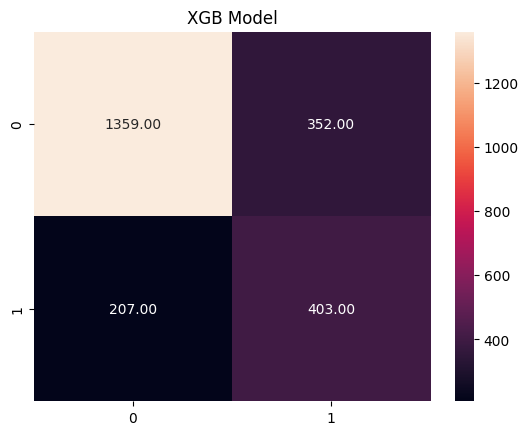

In [99]:
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt=".2f")
plt.title("XGB Model")

In [100]:
import joblib

In [101]:
joblib.dump(xgb_model, "XGBOOST_MODEL.pkl")
joblib.dump(scaler, "StandardScale.pkl")
joblib.dump(encoders, "LabelEncoder.pkl")

['LabelEncoder.pkl']

In [102]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')